In [3]:
import os
import time
from PIL import Image
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
os.environ['TFHUB_DOWNLOAD_PROGRESS'] = 'True'

In [4]:
!wget "https://user-images.githubusercontent.com/12981474/40157448-eff91f06-5953-11e8-9a37-f6b5693fa03f.png" -O original.png

--2026-09-10 15:45:19--  https://user-images.githubusercontent.com/12981474/40157448-eff91f06-5953-11e8-9a37-f6b5693fa03f.png
Resolving user-images.githubusercontent.com (user-images.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to user-images.githubusercontent.com (user-images.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 34146 (33K) [image/png]
Saving to: ‘original.png’

original.png        100%[===================>]  33.35K  --.-KB/s    in 0.003s  

2026-09-10 15:45:19 (12.9 MB/s) - ‘original.png’ saved [34146/34146]



In [8]:
# Declaring constants
IMAGE_PATH = "original.png"
SAVED_MODEL_PATH = "https://tfhub.dev/captain-pool/esrgan-tf2/1"

## Defining helper functions

In [9]:
def preprocess_image(image_path):
  hr_image = tf.image.decode_image(tf.io.read_file(image_path))
  # if png, remove the alpha channel . the model only supports
  # image with 3 color channels.
  if hr_image.shape[-1] == 4:
    hr_image = hr_image[...,:-1]
  hr_size = (tf.convert_to_tensor(hr_image.shape[:-1]) // 4) * 4
  hr_image = tf.image.crop_to_bounding_box(hr_image, 0, 0, hr_size[0], hr_size[1])
  hr_image = tf.cast(hr_image, tf.float32)
  return tf.expand_dims(hr_image, 0)

def save_image(image, filename):
  if not isinstance(image, Image.Image):
    image = tf.clip_by_value(image, 0, 255)
    image = Image.fromarray(tf.cast(image, tf.uint8).numpy())
  image.save("%s.png" % filename)
  print("Saved as %s.png" % filename)

In [10]:
%matplotlib inline
def plot_image(image, title=""):

  image = np.asarray(image)
  image = tf.clip_by_value(image, 0, 255)
  image = Image.fromarray(tf.cast(image, tf.uint8).numpy())
  plt.imshow(image)
  plt.axis("off")
  plt.title(title)

## Perfofrming super resolution of images loaded from path

In [11]:
hr_image = preprocess_image(IMAGE_PATH)

Saved as Original Image.png


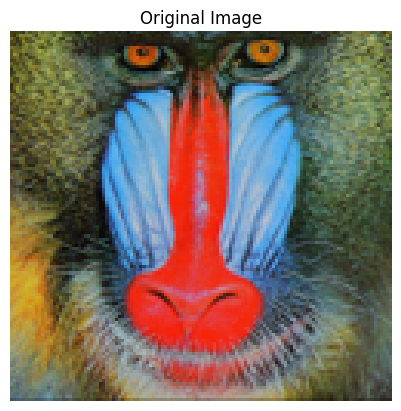

In [12]:
# Plotting Original Resolution image
plot_image(tf.squeeze(hr_image), title="Original Image")
save_image(tf.squeeze(hr_image), filename="Original Image")


In [13]:
model = hub.load(SAVED_MODEL_PATH)

Downloaded https://tfhub.dev/captain-pool/esrgan-tf2/1, Total size: 20.60MB



In [14]:
start = time.time()
fake_image = model(hr_image)
fake_image = tf.squeeze(fake_image)
print("Time Taken: %f" % (time.time() - start))

Time Taken: 3.681693


Saved as Super Resolution.png


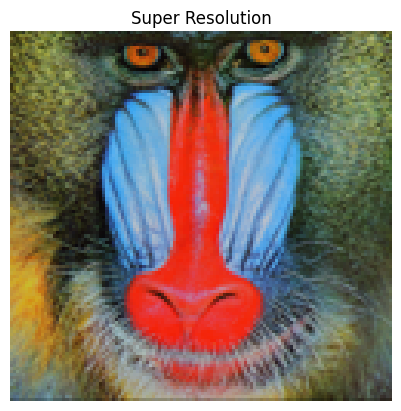

In [15]:
# Plotting Super Resolution image
plot_image(tf.squeeze(hr_image), title="Super Resolution")
save_image(tf.squeeze(hr_image), filename="Super Resolution")

## Evaluating Performance of the model


In [16]:
!wget "https://lh4.googleusercontent.com/-Anmw5df4gj0/AAAAAAAAAAI/AAAAAAAAAAc/6HxU8XFLnQE/photo.jpg64" -O test.jpg
IMAGE_PATH = "test.jpg"

--2026-09-10 16:07:10--  https://lh4.googleusercontent.com/-Anmw5df4gj0/AAAAAAAAAAI/AAAAAAAAAAc/6HxU8XFLnQE/photo.jpg64
Resolving lh4.googleusercontent.com (lh4.googleusercontent.com)... 142.250.99.132, 2607:f8b0:400e:c06::84
Connecting to lh4.googleusercontent.com (lh4.googleusercontent.com)|142.250.99.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 85465 (83K) [image/jpeg]
Saving to: ‘test.jpg’

test.jpg            100%[===================>]  83.46K  --.-KB/s    in 0.001s  

2026-09-10 16:07:10 (148 MB/s) - ‘test.jpg’ saved [85465/85465]



In [17]:
# Defining helper functions
def downscale_image(image):
  """
      Scales down images using bicubic downsampling.
      Args:
          image: 3D or 4D tensor of preprocessed image
  """
  image_size = []
  if len(image.shape) == 3:
    image_size = [image.shape[1], image.shape[0]]
  else:
    raise ValueError("Dimension mismatch. Can work only on single image.")

  image = tf.squeeze(
      tf.cast(
          tf.clip_by_value(image, 0, 255), tf.uint8))

  lr_image = np.asarray(
    Image.fromarray(image.numpy())
    .resize([image_size[0] // 4, image_size[1] // 4],
              Image.BICUBIC))

  lr_image = tf.expand_dims(lr_image, 0)
  lr_image = tf.cast(lr_image, tf.float32)
  return lr_image

In [18]:
hr_image=preprocess_image(IMAGE_PATH)

In [19]:
lr_image = downscale_image(tf.squeeze(hr_image))

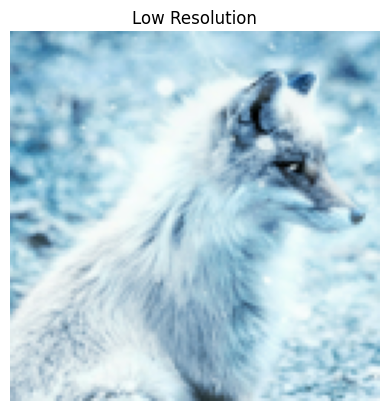

In [20]:
# Plotting Low resolution Image
plot_image(tf.squeeze(lr_image), title="Low Resolution")

In [21]:
model=hub.load(SAVED_MODEL_PATH)

In [22]:
start = time.time()
fake_image = model(lr_image)
fake_image = tf.squeeze(fake_image)
print("Time Taken: %f" % (time.time() - start))

Time Taken: 2.541431


PSNR Achieved: 27.938789


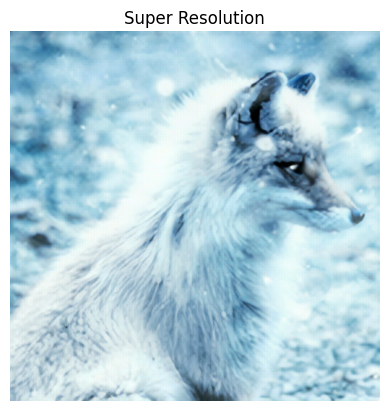

In [23]:
plot_image(tf.squeeze(fake_image), title="Super Resolution")

# claculating PSNR wrt original image
psnr = tf.image.psnr(
    tf.clip_by_value(fake_image, 0, 255),
    tf.clip_by_value(hr_image, 0, 255), max_val=255)
print("PSNR Achieved: %f" % psnr)


## Comparing outputs size by side

PSNR: 27.938789


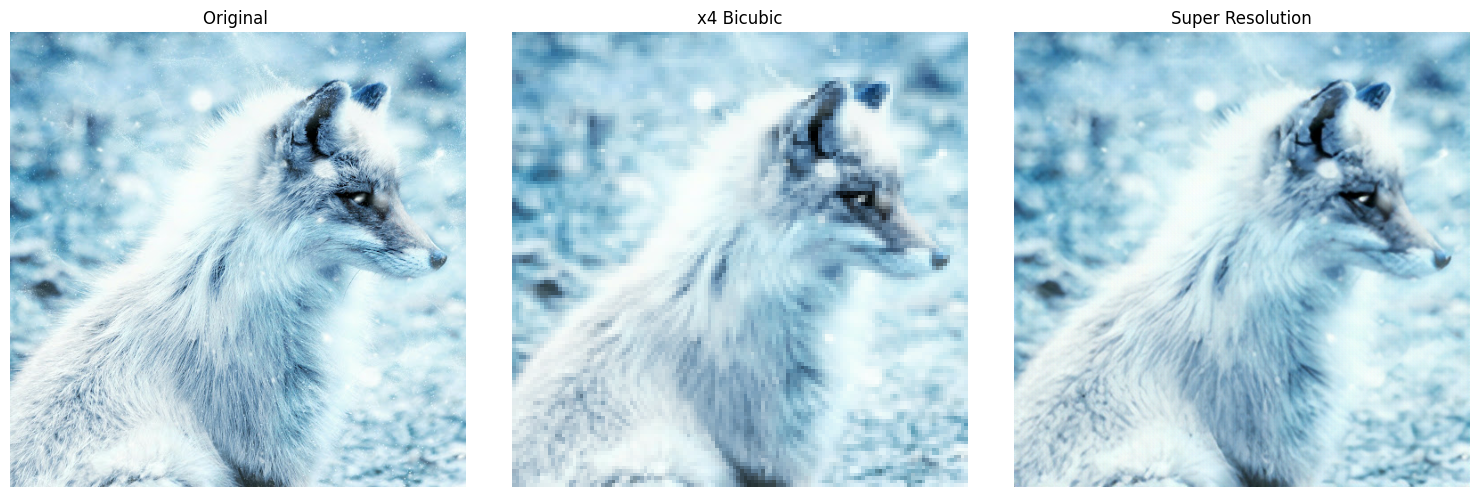

In [24]:
plt.rcParams['figure.figsize'] = [15, 10]
fig, axes = plt.subplots(1,3)
fig.tight_layout()
plt.subplot(131)
plot_image(tf.squeeze(hr_image), title="Original ")
plt.subplot(132)
fig.tight_layout()
plot_image(tf.squeeze(lr_image), "x4 Bicubic")
plt.subplot(133)
fig.tight_layout()
plot_image(tf.squeeze(fake_image), "Super Resolution")
plt.savefig("ESRGAN_DIV2K.jpg", bbox_inches="tight")
print("PSNR: %f" % psnr)